# Sewage tracer in the Greenport area (D-Flow FM)

Four-panel maps of the D-Flow FM sewage source/sink tracer (`mesh2d_sewage`,
kg m$^{-3}$) at 15 days, 1 month, 2 months, and 3 months of simulated time, for
each discretization (coarse / midres / highres). Each panel shows the tracer
field (log scale), the model grid, the Greenport MODFLOW model area, the
storm-sewer outfall, and a USGS topographic basemap.

The source/sink is the Greenport storm-sewer outfall on the east side of the
village (SWMM detailed-model node 171, `swmm/gp/gis/gp_junctions.shp`;
41.1046 N, 72.3592 W = UTM 18N 721754, 4553726). On the **coarse** grid the
2-km cell at the outfall is intertidal, so the coarse source is nudged to the
nearest always-wet cell; midres/highres resolve the outfall as a deep harbor
cell and use the outfall point directly.

For this demonstration the discharge onset was shifted to the simulation start
(2010-01-01) so the plume develops over the full 3-month period.

In [1]:
%matplotlib inline
import numpy as np
import pathlib as pl
import sys

import geopandas as gpd
import xugrid

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import flopy.plot.styles as styles

In [2]:
sys.path.append("../common")
from liss_settings import cx, cx_provider, set_title_string, fig_ext, transparent

#### Configuration

In [3]:
dflow_crs = 32618                       # D-Flow FM grid CRS (UTM 18N)
outfall_xy = (721753.58, 4553725.98)   # storm sewer outfall (SWMM node 171)

# one entry per discretization: map file + optional nudged source-cell marker
resolutions = {
    "coarse":  dict(map="../dflow-fm/coarse/tides_atm_surge/output/FlowFM_map.nc",
                    src_cell=(721859.40, 4555089.60)),   # nudged to nearest wet cell
    "midres":  dict(map="../dflow-fm/midres/tides_atm_surge/output/FlowFM_map.nc",
                    src_cell=None),
    "highres": dict(map="../dflow-fm/highres/tides_atm_surge/output/FlowFM_map.nc",
                    src_cell=None),
}

tracer_var = "mesh2d_sewage"
target_days = [15, 30, 60, 90]
panel_labels = ["15 days", "1 month", "2 months", "3 months"]
cmap = "turbo"
basemap_kwds = {"attribution": False, "source": cx_provider, "zoom": 11}
figsize = (9.5, 8.5)

fig_ws = pl.Path("figures")
fig_ws.mkdir(exist_ok=True, parents=True)

# Greenport MODFLOW model area (dissolved to a single outline), loaded once
gp_outline = (gpd.read_file("../modflow/gis/gp/gp_onshore_offshore_utm18n.shp")
              .to_crs(dflow_crs).dissolve())

#### Figure builder
`make_figure(name)` reads that discretization's map, picks the four output
times nearest the targets, auto-fits an extent around the plume + Greenport
model area + source, and draws the 4-panel figure (returns silently if the run
hasn't produced a map yet).

In [4]:
def make_figure(name):
    cfg = resolutions[name]
    mp = pl.Path(cfg["map"])
    if not mp.exists():
        print(f"[{name}] map not found ({mp}) - run the model first; skipping.")
        return
    ds = xugrid.open_dataset(mp)
    times = ds["time"].values
    grid_gdf = ds["mesh2d_nFaces"].ugrid.to_geodataframe(name="cell").set_crs(dflow_crs)

    elapsed = (times - times[0]) / np.timedelta64(1, "D")
    tidx = [int(np.argmin(np.abs(elapsed - d))) for d in target_days]

    fx = ds["mesh2d_face_x"].values
    fy = ds["mesh2d_face_y"].values
    tr_final = ds[tracer_var].isel(time=tidx[-1]).values
    fmax = float(np.nanmax(tr_final))
    conc_max = fmax if fmax > 0 else 1.0
    conc_min = conc_max / 100.0        # adaptive 2-decade log range per grid
    plume = tr_final > conc_min
    if plume.any():
        pb = [fx[plume].min(), fy[plume].min(), fx[plume].max(), fy[plume].max()]
    else:
        pb = list(gp_outline.total_bounds)

    gb = gp_outline.total_bounds
    sx = [outfall_xy[0]] + ([cfg["src_cell"][0]] if cfg["src_cell"] else [])
    sy = [outfall_xy[1]] + ([cfg["src_cell"][1]] if cfg["src_cell"] else [])
    xmin = min(pb[0], gb[0], *sx); ymin = min(pb[1], gb[1], *sy)
    xmax = max(pb[2], gb[2], *sx); ymax = max(pb[3], gb[3], *sy)
    m = max(0.12 * (xmax - xmin), 0.12 * (ymax - ymin))
    ex, ey = (xmin - m, xmax + m), (ymin - m, ymax + m)

    norm = mcolors.LogNorm(vmin=conc_min, vmax=conc_max)

    def masked(idx):
        v = ds[tracer_var].isel(time=idx).values.astype(float).copy()
        v[v <= conc_min] = np.nan
        return v

    with styles.USGSMap():
        fig, axs = plt.subplots(2, 2, figsize=figsize, layout="constrained")
        axs = axs.ravel()
        pc = None
        for ax, idx, lbl in zip(axs, tidx, panel_labels):
            grid_gdf.plot(ax=ax, fc="none", ec="0.35", lw=0.1, zorder=2)
            p = ds[tracer_var].isel(time=idx).ugrid.plot(
                ax=ax, cmap=cmap, norm=norm, lw=0.0, add_colorbar=False, zorder=3)
            p.set_array(masked(idx)); pc = p
            gp_outline.boundary.plot(ax=ax, ec="white", lw=1.6, zorder=4)
            gp_outline.boundary.plot(ax=ax, ec="black", lw=0.8, zorder=5)
            ax.plot(*outfall_xy, marker="*", ms=13, mfc="white", mec="black",
                    mew=1.0, ls="none", zorder=7, label="storm sewer outfall (node 171)")
            if cfg["src_cell"]:
                ax.plot(*cfg["src_cell"], marker="o", ms=7, mfc="none", mec="black",
                        mew=1.3, ls="none", zorder=6, label="coarse source cell (nudged)")
            cx.add_basemap(ax, crs=dflow_crs, **basemap_kwds)
            ax.set_xlim(ex); ax.set_ylim(ey)
            ax.set_xlabel(None); ax.set_ylabel(None)
            ax.set_xticklabels([]); ax.set_yticklabels([])
            ax.set_title(f"{lbl}  ({set_title_string(times[idx])})", size=8)
            styles.add_text(ax, text=lbl, x=0.03, y=0.97, bold=True, va="top", ha="left")

        axs[0].legend(loc="lower left", fontsize=6, framealpha=0.85)
        cb = fig.colorbar(pc, ax=axs, shrink=0.6, extend="max", location="right")
        cb.set_label("Sewage tracer concentration (kg m$^{-3}$)", size=8)
        fig.suptitle(f"Greenport sewage tracer - {name} D-Flow FM model", fontsize=10)
        fig.savefig(fig_ws / f"greenport_tracer_4panel_{name}{fig_ext}",
                    dpi=300, transparent=transparent)
    ds.close()
    print(f"[{name}] wrote greenport_tracer_4panel_{name}{fig_ext}")

#### Coarse

[coarse] wrote greenport_tracer_4panel_coarse.png


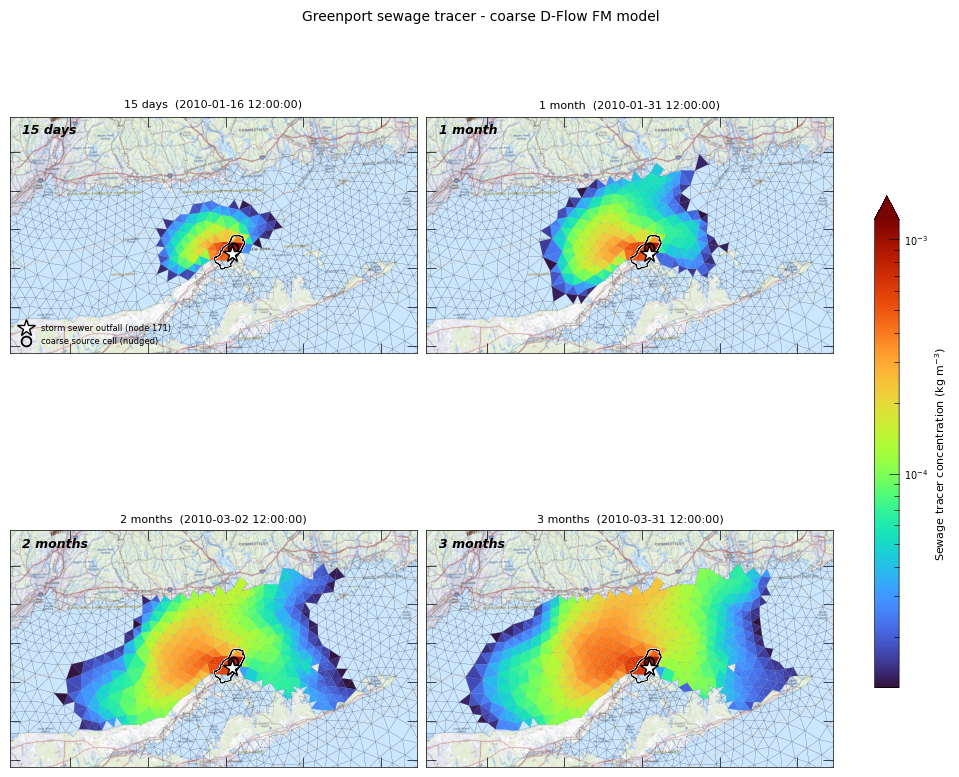

In [5]:
make_figure("coarse")

#### Midres

[midres] wrote greenport_tracer_4panel_midres.png


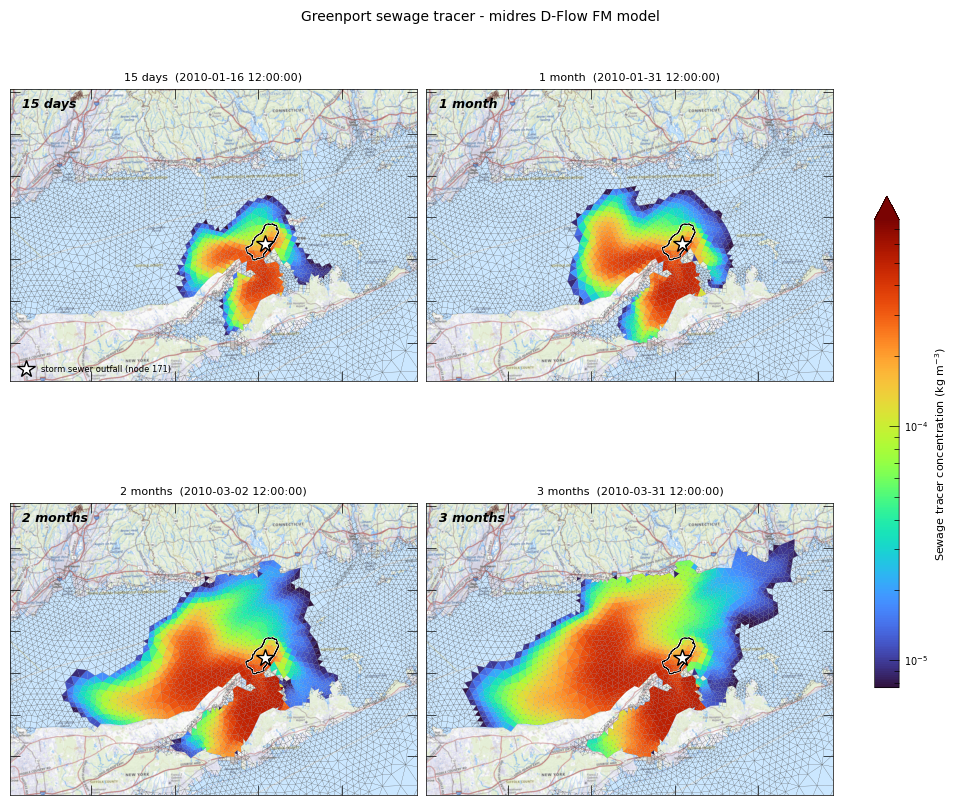

In [6]:
make_figure("midres")

#### Highres

[highres] wrote greenport_tracer_4panel_highres.png


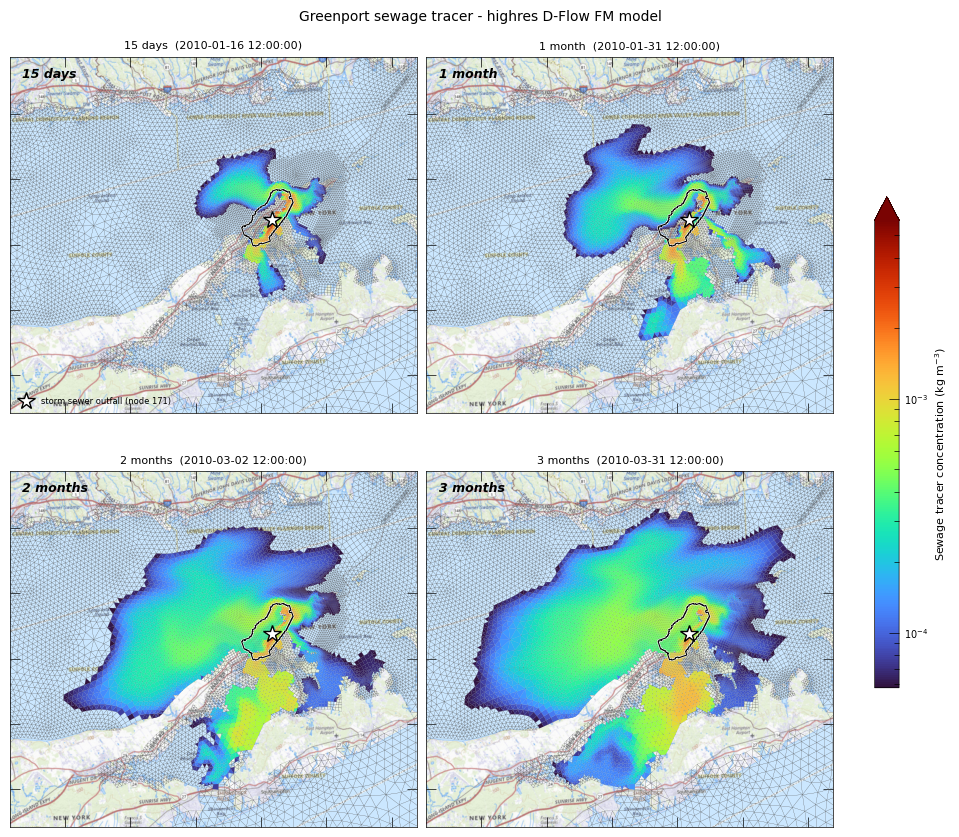

In [7]:
make_figure("highres")